| Company        | Ticker |
| -------------- | ------ |
| Microsoft      | MSFT   |
| Apple          | AAPL   |
| Amazon         | AMZN   |
| Tesla, Inc.    | TSLA   |
| NVIDIA         | NVDA   |

### India Stocks
| Company                   | Ticker      |
| ------------------------- | ----------- |
| Reliance Industries       | RELIANCE.NS |
| Tata Consultancy Services | TCS.NS      |
| Infosys                   | INFY.NS     |
| HDFC Bank                 | HDFCBANK.NS |
    
### Indices
| Index                        | Ticker |
| ---------------------------- | ------ |
| S&P 500                      | ^GSPC  |
| NIFTY 50                     | ^NSEI  |


In [1]:
import yfinance as yf

data = yf.download("MSFT", start="2020-01-01")

# print(data)

data.to_csv("msft.csv")

[*********************100%***********************]  1 of 1 completed


In [2]:
import pandas as pd

df = pd.read_csv('msft.csv')

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,152.15843200683594,152.26263771533866,149.9890770179385,150.41536784183276,22622100
3,2020-01-03,150.2637176513672,151.52365350919996,149.7332213859511,149.9795335484222,21116200
4,2020-01-06,150.65213012695312,150.7184493912366,148.26488234672686,148.8048610818125,20813700


In [3]:
df = df.dropna()
df = df.drop_duplicates()

In [4]:
# reset index so Date becomes a column
df = df.drop(0)   # removes row with index 0,1
df = df.reset_index(drop=True)
df = df.rename(columns={"Price": "Date",})
# rename columns
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,152.15843200683594,152.26263771533866,149.9890770179385,150.41536784183276,22622100
1,2020-01-03,150.2637176513672,151.52365350919996,149.7332213859511,149.9795335484222,21116200
2,2020-01-06,150.65213012695312,150.7184493912366,148.26488234672686,148.8048610818125,20813700
3,2020-01-07,149.27853393554688,151.2584272318134,149.03223619242732,150.92687424549183,21634100
4,2020-01-08,151.6563262939453,152.32892928184137,149.6290637970409,150.55743255975017,27746500


In [5]:
df.dtypes

Date      str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [6]:
cols = df.columns.drop(["Date"])
df[cols] = df[cols].astype(float)

In [7]:
df.dtypes

Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

In [8]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [9]:
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1571   2026-04-06
1572   2026-04-07
1573   2026-04-08
1574   2026-04-09
1575   2026-04-10
Name: Date, Length: 1576, dtype: datetime64[us]

In [10]:
df.index = df.pop('Date')
df

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,152.158432,152.262638,149.989077,150.415368,22622100.0
2020-01-03,150.263718,151.523654,149.733221,149.979534,21116200.0
2020-01-06,150.652130,150.718449,148.264882,148.804861,20813700.0
2020-01-07,149.278534,151.258427,149.032236,150.926874,21634100.0
2020-01-08,151.656326,152.328929,149.629064,150.557433,27746500.0
...,...,...,...,...,...
2026-04-06,372.880005,373.730011,369.500000,373.489990,16146600.0
2026-04-07,372.290009,372.450012,366.559998,370.339996,21443300.0
2026-04-08,374.329987,385.000000,371.410004,384.980011,33064800.0


In [11]:
from sklearn.preprocessing import MinMaxScaler

X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()
temp = df[['Close']]

df[cols]= X_scaler.fit_transform(df[cols])

df[['Close']] = Y_scaler.fit_transform(temp)

In [12]:
import joblib

joblib.dump(X_scaler, "X_scaler.pkl")
joblib.dump(Y_scaler, "Y_scaler.pkl")

['Y_scaler.pkl']

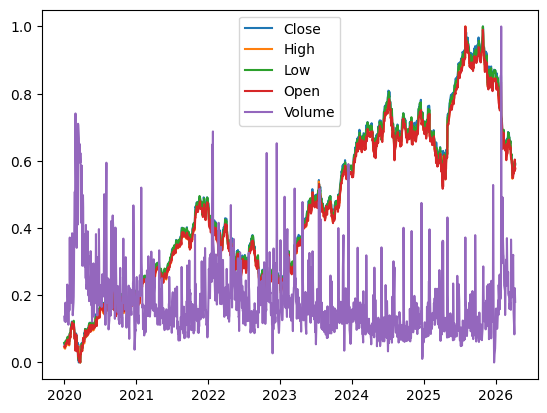

In [13]:
import matplotlib.pyplot as plt
for col in cols:
    plt.plot(df.index, df[col],label = col)

plt.legend()
plt.show()

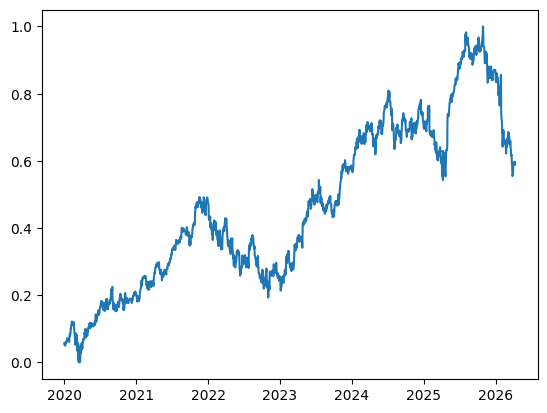

In [14]:
plt.plot(df.index, df["Close"])

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [15]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
    first_date = str_to_datetime(first_date_str)
    last_date  = str_to_datetime(last_date_str)

    target_date = first_date

    dates = []
    X, Y = [], []

    last_time = False
    while True:
        df_subset = dataframe.loc[:target_date].tail(n+1)

        if len(df_subset) != n+1:
            print(f'Error: Window of size {n} is too large for date {target_date}')
            return

        values = df_subset[cols].to_numpy()
        x, y = values[:-1], values[-1][0]
        
        dates.append(target_date)
        X.append(x)
        Y.append(y)

        # stock markets are closed on sat,sun adn holidays so no data available for those days
        # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
        next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
        # chooses the next trading day top one is the previous trading day ,next one is the next trading day
        next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
        next_date_str = next_datetime_str.split('T')[0]
        next_date = str_to_datetime(next_date_str)

        if last_time:
            break

        target_date = next_date

        if target_date == last_date:
            last_time = True

    return np.array(dates),np.array(X), np.array(Y)

# Start day second time around: '2021-03-25'
dates,X,y = df_to_windowed_df(df,
                                '2020-04-01',
                                '2026-4-01',
                                n=16)
print(X)
print(y)

[[[0.0589088  0.0464162  0.0461776  0.04762187 0.48373   ]
  [0.04206783 0.03886164 0.04288575 0.04530268 0.41069875]
  [0.00840896 0.02926534 0.01394996 0.01866598 0.71033273]
  ...
  [0.03298879 0.03248665 0.03839676 0.0331888  0.41615162]
  [0.05731474 0.04544066 0.04026147 0.03474254 0.46800553]
  [0.05149324 0.05492356 0.05533944 0.05041385 0.58594839]]

 [[0.04206783 0.03886164 0.04288575 0.04530268 0.41069875]
  [0.00840896 0.02926534 0.01394996 0.01866598 0.71033273]
  [0.05408048 0.04841249 0.0188991  0.02361946 0.7062758 ]
  ...
  [0.05731474 0.04544066 0.04026147 0.03474254 0.46800553]
  [0.05149324 0.05492356 0.05533944 0.05041385 0.58594839]
  [0.03855635 0.03897504 0.04212609 0.03600343 0.42369312]]

 [[0.00840896 0.02926534 0.01394996 0.01866598 0.71033273]
  [0.05408048 0.04841249 0.0188991  0.02361946 0.7062758 ]
  [0.         0.01991856 0.00570887 0.00673235 0.66707642]
  ...
  [0.05149324 0.05492356 0.05533944 0.05041385 0.58594839]
  [0.03855635 0.03897504 0.0421260

In [16]:
print(dates.shape)
print(X.shape)
print(y.shape)

(1508,)
(1508, 16, 5)
(1508,)


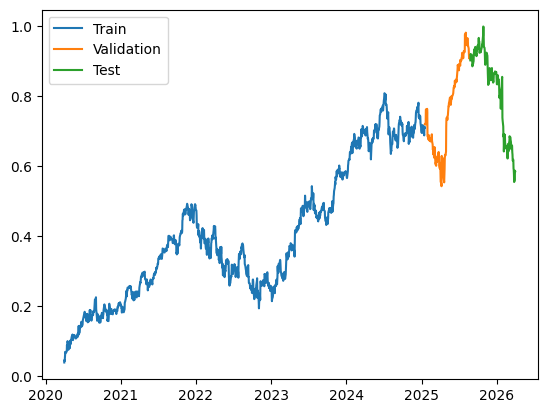

In [17]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train = dates[:q_80], X[:q_80,:,:], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((40, 5)),
                    layers.Conv1D(64, 3, activation='relu'),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=500)

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0249 - mean_absolute_error: 0.1039 - val_loss: 0.0025 - val_mean_absolute_error: 0.0429
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2906e-04 - mean_absolute_error: 0.0164 - val_loss: 0.0020 - val_mean_absolute_error: 0.0390
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7031e-04 - mean_absolute_error: 0.0154 - val_loss: 0.0015 - val_mean_absolute_error: 0.0336
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9156e-04 - mean_absolute_error: 0.0158 - val_loss: 0.0018 - val_mean_absolute_error: 0.0369
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.7086e-04 - mean_absolute_error: 0.0152 - val_loss: 0.0020 - val_mean_absolute_error: 0.0384
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.7054e-04 - mean_absolute_error: 0.0152 - val_loss: 0.0014 - val_mean_absolute_error: 0.0329
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7958e-04 - mean_ab

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


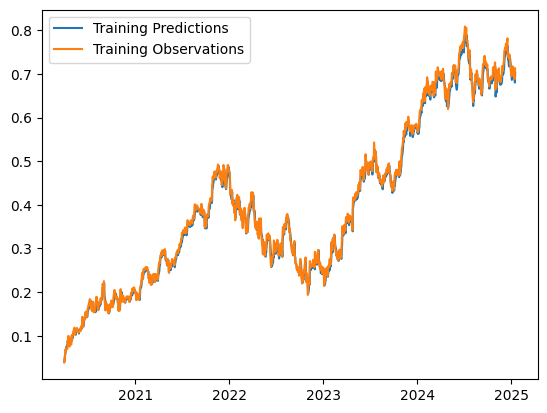

In [19]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


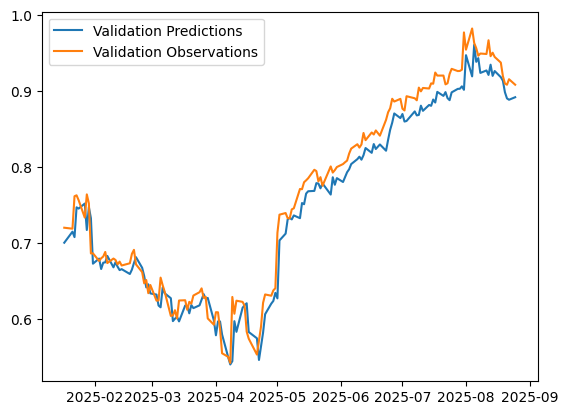

In [20]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


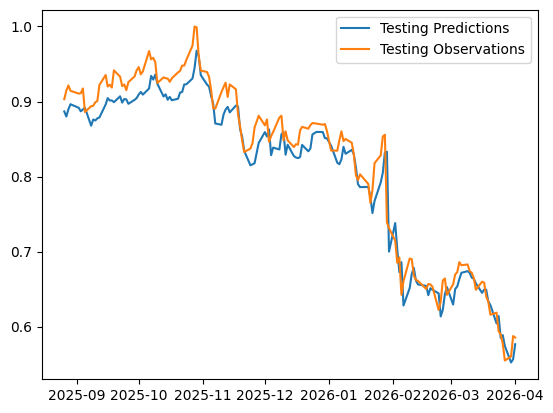

In [21]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [22]:
model.save("microsoft_stock_model.keras")

In [23]:
print("X scaler min:", X_scaler.data_min_)
print("X scaler max:", X_scaler.data_max_)
print("X scaler range:", X_scaler.data_range_)
print("X scaler scale:", X_scaler.scale_)
print("X scaler min offset:", X_scaler.min_)

X scaler min: [1.28636337e+02 1.33528371e+02 1.25881621e+02 1.30146692e+02
 5.85590000e+06]
X scaler max: [5.39825195e+02 5.52242002e+02 5.38530591e+02 5.52023241e+02
 1.28855300e+08]
X scaler range: [4.11188858e+02 4.18713630e+02 4.12648970e+02 4.21876549e+02
 1.22999400e+08]
X scaler scale: [2.43197251e-03 2.38826713e-03 2.42336725e-03 2.37036167e-03
 8.13012096e-09]
X scaler min offset: [-0.31284004 -0.31890142 -0.3050574  -0.30849473 -0.04760918]


In [24]:
print("Y scaler min:", Y_scaler.data_min_)
print("Y scaler max:", Y_scaler.data_max_)
print("Y scaler range:", Y_scaler.data_range_)
print("Y scaler scale:", Y_scaler.scale_)
print("Y scaler min offset:", Y_scaler.min_)

Y scaler min: [128.63633728]
Y scaler max: [539.82519531]
Y scaler range: [411.18885803]
Y scaler scale: [0.00243197]
Y scaler min offset: [-0.31284004]


In [25]:
import yfinance as yf
import numpy as np
import joblib
from tensorflow import keras

# feature columns
cols = ["Open", "High", "Low", "Close", "Volume"]

# load model
model = keras.models.load_model("E:/3rd_sem_project/stock_price_predictor_models/v1/microsoft_stock_model.keras")

# load scalers
X_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/X_scaler.pkl")
Y_scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/Y_scaler.pkl")

# choose ticker
ticker = "MSFT"

# download last 80 days
data = yf.download(ticker, period="40d")

print(data)

# take last 40 days
prices = data[cols].tail(16).values

# scale features
scaled = X_scaler.transform(prices)

# reshape for model (1 sample, 16 timesteps, 5 features)
X_input = scaled.reshape(1, 16, 5)

# predict
pred_scaled = model.predict(X_input)

# convert prediction back to real price
pred_price = Y_scaler.inverse_transform(pred_scaled)

print("Predicted next price:", pred_price[0][0])

[*********************100%***********************]  1 of 1 completed
E:\3rd_sem_project\stock_price_predictor_models\v1\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2026-02-12  400.924896  405.274983  397.103632  404.077704  40802400
2026-02-13  400.406097  404.616489  397.143525  403.528974  34091600
2026-02-17  395.956238  399.607907  393.631557  398.310879  32078800
2026-02-18  398.690002  401.643253  395.417473  397.223349  23223400
2026-02-19  398.459991  404.429993  396.670013  400.690002  28234000
2026-02-20  397.230011  400.119995  395.160004  396.109985  34015200
2026-02-23  384.470001  395.359985  383.100006  395.000000  43238300
2026-02-24  389.000000  389.359985  381.709991  384.140015  33884700
2026-02-25  400.600006  401.470001  390.160004  390.529999  43625500
2026-02-26  401.720001  407.489990  398.739990  404.709991  34405900
2026-02-27  392.739990  396.820007  389.880005  390.880005  51367200
2026-03-02  398.549988  401.190002